# Swiss Roll & Kernel PCA: Nonlinear Manifold Unfolding

This notebook demonstrates why linear PCA fails on nonlinear manifolds
and how Kernel PCA can partially recover nonlinear structure.

We analyze:

• Swiss Roll geometry  
• Linear PCA projection  
• RBF Kernel PCA  
• Effect of gamma  
• Geometric interpretation

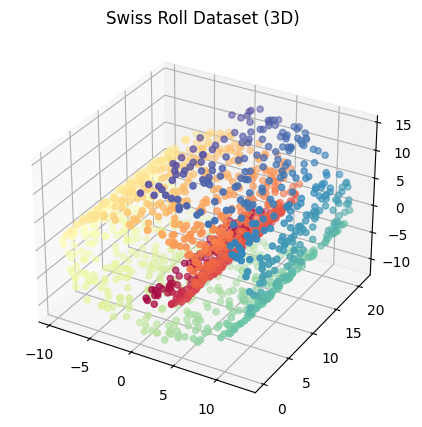

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll

X, t = make_swiss_roll(n_samples=1500, noise=0.1, random_state=42)

fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(projection='3d')
ax.scatter(X[:,0], X[:,1], X[:,2], c=t, cmap="Spectral")
ax.set_title("Swiss Roll Dataset (3D)")
plt.show()

## Swiss Roll Geometry

Swiss roll lies on a 2D manifold embedded in 3D space.

Intrinsic dimension = 2  
Ambient dimension = 3  

The roll structure makes linear projection insufficient.

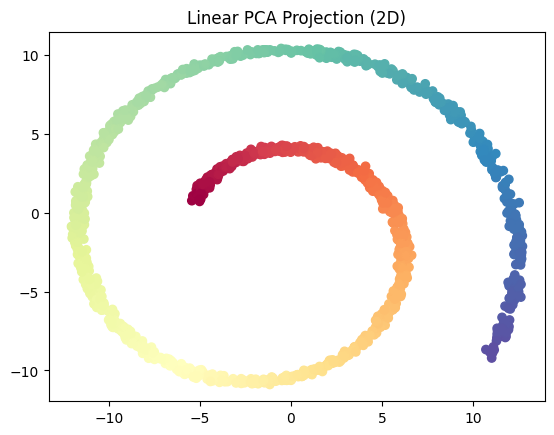

In [2]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1], c=t, cmap="Spectral")
plt.title("Linear PCA Projection (2D)")
plt.show()

### Observation

Linear PCA flattens the roll but overlapping layers remain.

The structure is distorted because PCA only performs linear projection.

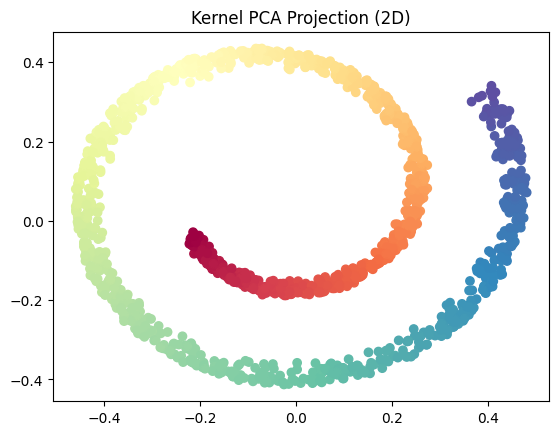

In [3]:
from sklearn.decomposition import KernelPCA

kpca = KernelPCA(
    n_components=2,
    kernel="rbf",
    gamma=0.001
)

X_kpca = kpca.fit_transform(X)

plt.scatter(X_kpca[:,0], X_kpca[:,1], c=t, cmap="Spectral")
plt.title("Kernel PCA Projection (2D)")
plt.show()

### Observation

Kernel PCA partially unfolds the roll.

Nonlinear similarity allows curved manifold to become separable.

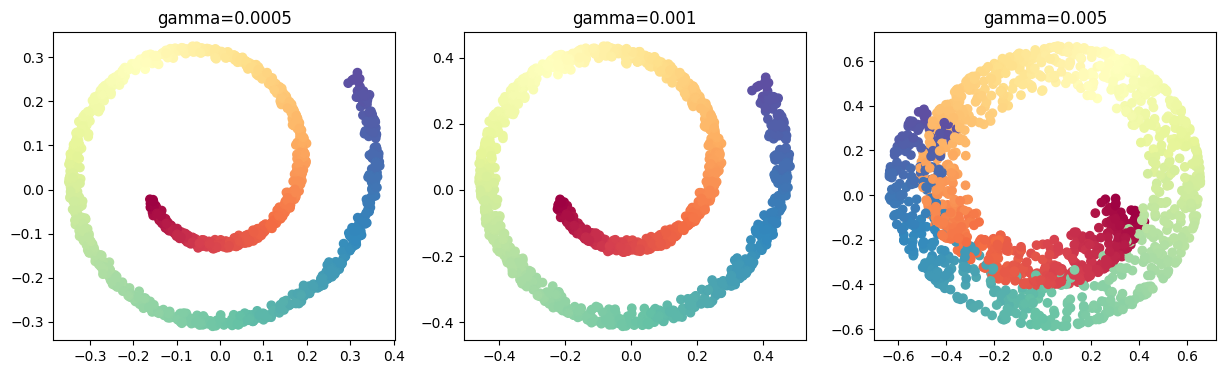

In [4]:
gammas = [0.0005, 0.001, 0.005]

fig, axes = plt.subplots(1,3, figsize=(15,4))

for gamma, ax in zip(gammas, axes):
    kpca = KernelPCA(n_components=2, kernel="rbf", gamma=gamma)
    X_kpca = kpca.fit_transform(X)
    ax.scatter(X_kpca[:,0], X_kpca[:,1], c=t, cmap="Spectral")
    ax.set_title(f"gamma={gamma}")

plt.show()

### Effect of Gamma

Small gamma → smoother unfolding  
Large gamma → fragmented projection  

Gamma controls locality of similarity in high-dimensional space.

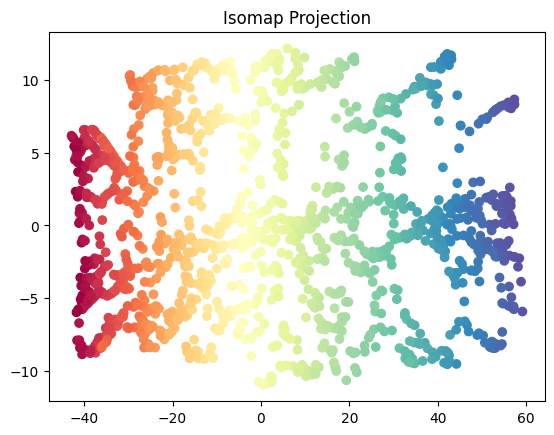

In [5]:
from sklearn.manifold import Isomap

isomap = Isomap(n_components=2)
X_iso = isomap.fit_transform(X)

plt.scatter(X_iso[:,0], X_iso[:,1], c=t, cmap="Spectral")
plt.title("Isomap Projection")
plt.show()

### Interpretation

Isomap explicitly preserves geodesic distances,
producing a more faithful unfolding than Kernel PCA.

Kernel PCA is spectral but not geodesic-aware.

## Why Kernel PCA Works Here

Kernel PCA computes eigenvectors of:

Kᵢⱼ = exp(-γ ||xᵢ - xⱼ||²)

This captures nonlinear similarity.

Eigenvectors represent principal directions in implicit feature space.

Projection corresponds to nonlinear transformation in original space.

### Computational Note
Kernel PCA requires eigen-decomposition of n × n matrix.

Memory: O(n²)  
Time: O(n³)

Thus, Kernel PCA does not scale well for very large datasets.

# Final Insights

• Swiss roll demonstrates nonlinear manifold structure  
• Linear PCA fails due to linear projection limitation  
• Kernel PCA captures nonlinear similarity  
• Gamma controls locality  
• Kernel methods scale poorly with sample size  

Kernel PCA is powerful but computationally expensive.